# DESI BGS Simulations

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.lumMag_sampling import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

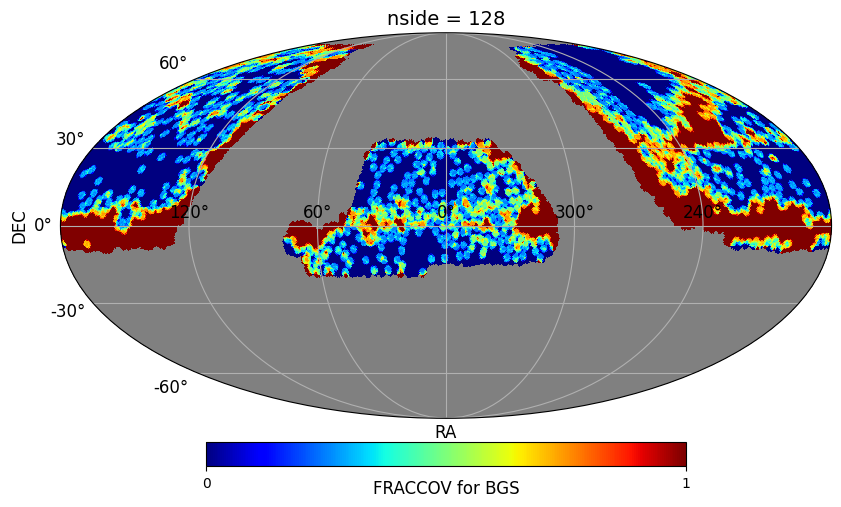

In [3]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-bright.fits"

sources="BGS"

outputDIR = DIR + f"DESI Figures/DESI DR1 {sources}/" #to save figures
output_path_data = outputDIR + f"DESI_DR1_{sources}_Data/" #common suffix to every figures
output_path_Simu = outputDIR + f"DESI_DR1_{sources}_Simul/"
suffix_data = f"DESI_DR1_{sources}_Density_map_"
suffix_Simu = f"DESI_DR1_{sources}_Simul_Density_map_"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

### From DESI data

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.712e+07 (χ²/ndof = 87.1) │              Nfcn = 351              │
│ EDM = 1.93e-06 (Goal: 0.0002)    │           time = 17.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  205.65   │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 1 │ A    │ 634.2e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │    0    │    1    │       │
│ 2 │ ra   │  229.90   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -50.72   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.09   │   0.09    │  -0.7e-3  │  0.7e-3   │   -0.07   │   0.07    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0076  26.2e-6   -0.001  -0.0025 │
│   A │  26.2e-6 4.44e-07   0.8e-6 -11.0e-6 │
│  ra │   -0.001   0.8e-6  0.00492   0.0013 │
│ dec │  -0.0025 -11.0e-6   0.0013  0.00278 │
└─────┴─────────────────────────────────────┘

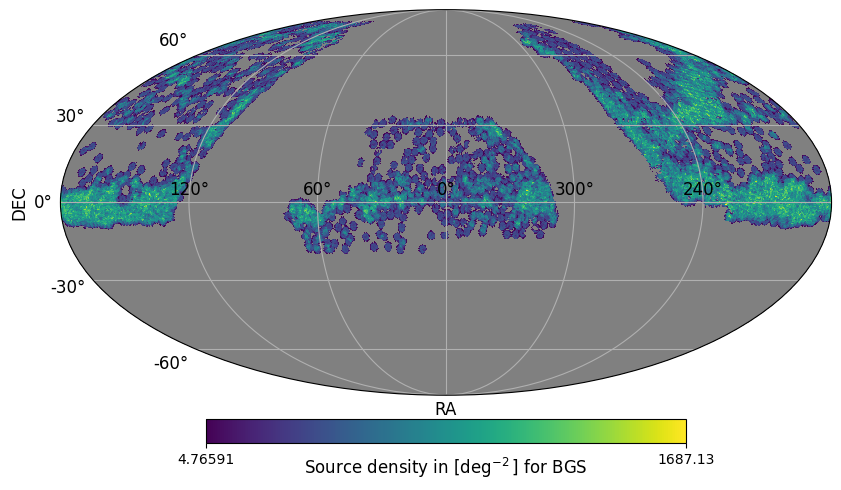

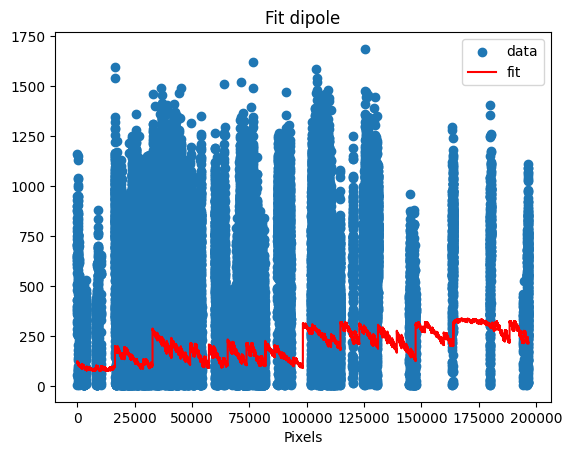

In [4]:
#File names:
FILE_NGC = DIR + "BGS_ANY_NGC_clustering.dat.fits"
FILE_SGC = DIR + "BGS_ANY_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
ALL_Mapper = NGC_Mapper.add(SGC_Mapper)
ALL_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
ALL_Mapper.set_mask()
# ALL_Mapper.plot("Masked")
# get_savefig(plt, output_path_data, suffix_data+"mask0");

#Fitting dipole:
init =  (200, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.93e+06 (χ²/ndof = 40.3)  │              Nfcn = 400              │
│ EDM = 4.25e-05 (Goal: 0.0002)    │           time = 24.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  383.30   │   0.15    │   -0.15    │    0.15    │    0    │         │       │
│ 1 │ A    │ 580.6e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │    0    │    1    │       │
│ 2 │ ra   │  216.78   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -44.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.15   │   0.15    │  -0.6e-3  │  0.6e-3   │   -0.07   │   0.07    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0218  22.5e-6    0.000  -0.0053 │
│   A │  22.5e-6 3.69e-07   4.7e-6 -11.9e-6 │
│  ra │    0.000   4.7e-6  0.00433  -0.0000 │
│ dec │  -0.0053 -11.9e-6  -0.0000  0.00352 │
└─────┴─────────────────────────────────────┘

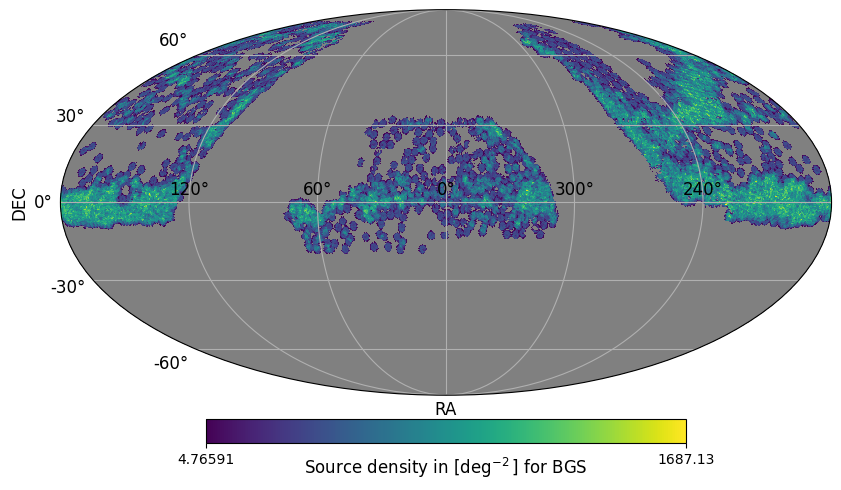

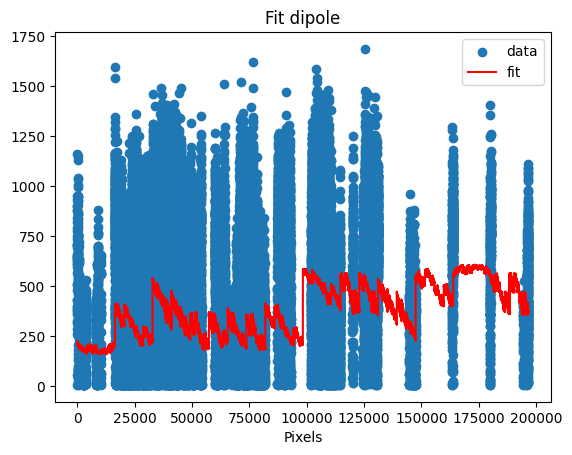

In [5]:
init =  (200, 1, 100, 40)
m = ALL_Mapper.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From simulation

Total number of sources in the entire sky : 69599232
Theorical number of sources in one pixel : 354


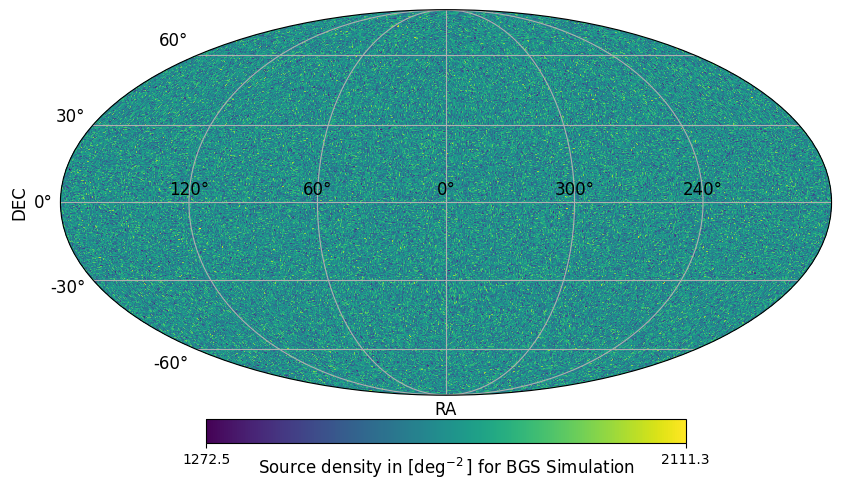

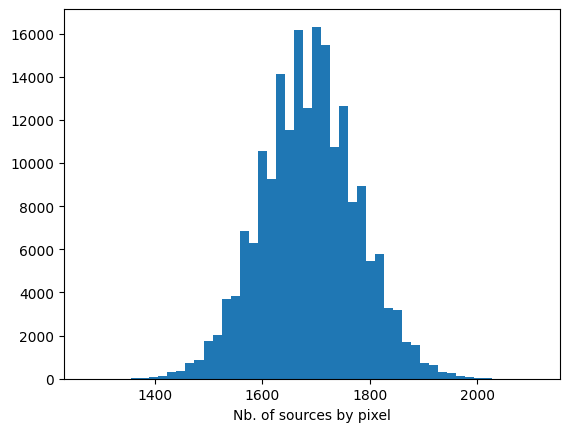

In [6]:
NSource_px_th = int(ALL_Mapper.map.max() * ALL_Mapper.area_deg2)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

#data = generate_lumMag(NSource_px_th*npix, to_table=True)
data = {}
data["RA"], data["DEC"] = generate_raDec(NSource_px_th*npix)
data = Table(data)

simu_Mapper = DensityMapper(data, nside=nside)
simu_Mapper._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper.plot('')

get_hist(simu_Mapper.map, bins=50);

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.386e+05 (χ²/ndof = 1.2)  │              Nfcn = 731              │
│ EDM = 1.41e-06 (Goal: 0.0002)    │           time = 44.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.68319e3 │ 0.00018e3 │ -0.00018e3 │ 0.00018e3  │    0    │         │       │
│ 1 │ A    │  0.11e-9  │207113.18e-9│  -0.11e-9  │207113.18e-9│    0    │    1    │       │
│ 2 │ ra   │  0.17e3   │  0.26e3   │  -0.17e3   │   0.19e3   │    0    │   360   │       │
│ 3 │ dec  │   -87.1   │   141.4   │    -2.9    │   141.4    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.18   │   0.18    │ -0.11e-9  │207113.18e-9│  -0.17e3  │  0.19e3   │   -2.9    │   141.4   │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   True    │   False   │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────┐
│     │            N*             A            ra           dec │
├─────┼─────────────────────────────────────────────────────────┤
│  N* │        0.0333   -263.98e-12        -0.002         0.001 │
│   A │   -263.98e-12      9.35e-14  657.25989e-9 -344.53895e-9 │
│  ra │        -0.002  657.25989e-9      1.29e+05            -0 │
│ dec │         0.001 -344.53895e-9            -0      2.04e+03 │
└─────┴─────────────────────────────────────────────────────────┘

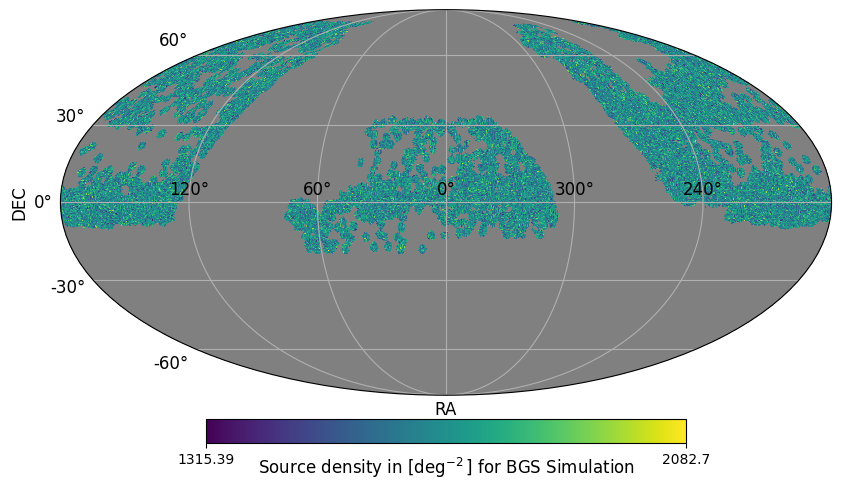

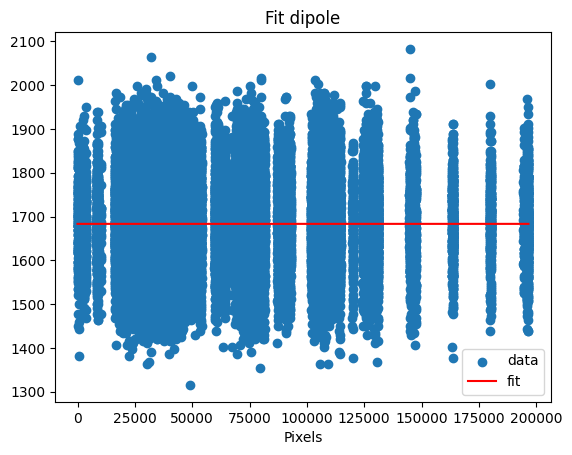

In [7]:
simu_Mapper.set_mask(mask=ALL_Mapper.mapMasked.mask)

init =  (200, 0, 100, 40)
m = simu_Mapper.fit_dipole("Masked", init)
m

### FRACCOV rescaling

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.136e+07 (χ²/ndof = 159.5)│              Nfcn = 418              │
│ EDM = 4.26e-06 (Goal: 0.0002)    │           time = 19.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  398.64   │   0.12    │   -0.12    │    0.12    │    0    │         │       │
│ 1 │ A    │ 661.4e-3  │  0.5e-3   │  -0.5e-3   │   0.5e-3   │    0    │    1    │       │
│ 2 │ ra   │  238.73   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │  -50.87   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.12   │   0.12    │  -0.5e-3  │  0.5e-3   │   -0.05   │   0.05    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0149 27.59e-6  -0.0011  -0.0027 │
│   A │ 27.59e-6 2.32e-07 -2.31e-6 -5.86e-6 │
│  ra │  -0.0011 -2.31e-6  0.00219   0.0009 │
│ dec │  -0.0027 -5.86e-6   0.0009  0.00152 │
└─────┴─────────────────────────────────────┘

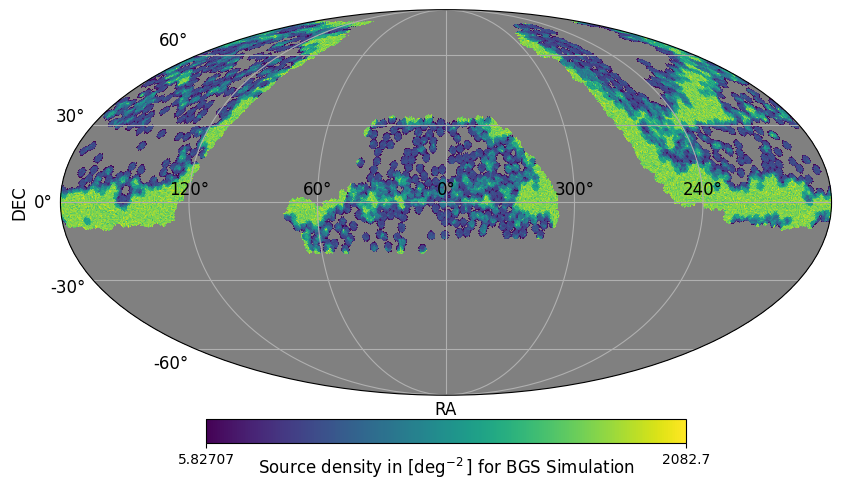

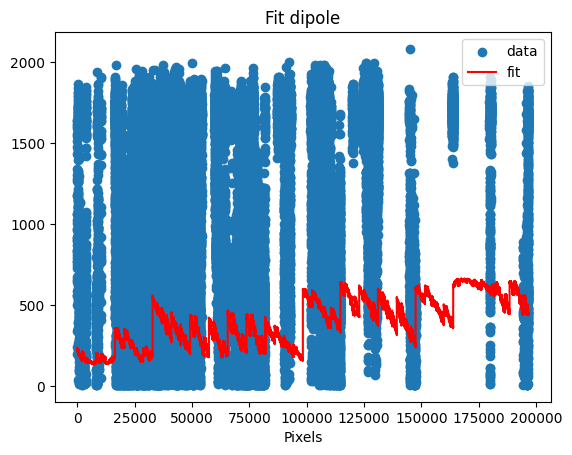

In [8]:
hpmap = simu_Mapper.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_scale = DensityMapper.from_map(hpmap)
simu_Mapper_scale._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_scale.set_mask()
# simu_Mapper_scale.plot("Masked")
# get_savefig(plt, output_path_Simu, suffix_Simu+"mask0");

init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.328e+06 (χ²/ndof = 42.4) │              Nfcn = 481              │
│ EDM = 0.000132 (Goal: 0.0002)    │           time = 30.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.05545e3 │ 0.00025e3 │ -0.00025e3 │ 0.00025e3  │    0    │         │       │
│ 1 │ A    │ 492.7e-3  │  0.4e-3   │  -0.4e-3   │   0.4e-3   │    0    │    1    │       │
│ 2 │ ra   │  217.74   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -58.07   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.25   │   0.25    │  -0.4e-3  │  0.4e-3   │   -0.07   │   0.07    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0613 42.99e-6   -0.001  -0.0052 │
│   A │ 42.99e-6 1.79e-07  0.76e-6 -5.34e-6 │
│  ra │   -0.001  0.76e-6  0.00437   0.0005 │
│ dec │  -0.0052 -5.34e-6   0.0005  0.00133 │
└─────┴─────────────────────────────────────┘

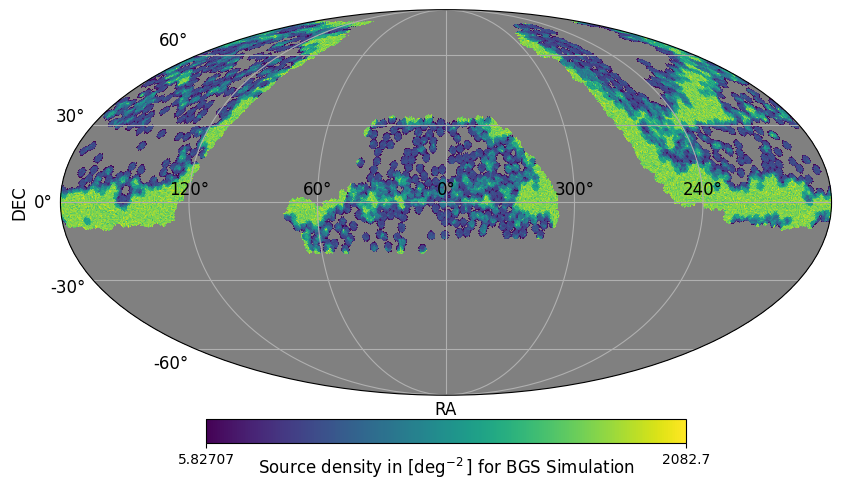

/home/victoria/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


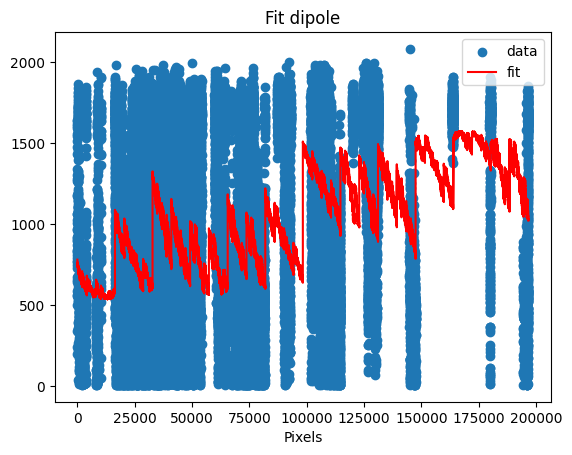

In [9]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From Poisson noise

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.134e+07 (χ²/ndof = 159.4)│              Nfcn = 426              │
│ EDM = 2.04e-05 (Goal: 0.0002)    │           time = 25.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  398.13   │   0.12    │   -0.12    │    0.12    │    0    │         │       │
│ 1 │ A    │ 661.8e-3  │  0.5e-3   │  -0.5e-3   │   0.5e-3   │    0    │    1    │       │
│ 2 │ ra   │  239.06   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │  -50.51   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.12   │   0.12    │  -0.5e-3  │  0.5e-3   │   -0.05   │   0.05    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0149 27.43e-6  -0.0011  -0.0027 │
│   A │ 27.43e-6 2.31e-07 -2.27e-6 -5.92e-6 │
│  ra │  -0.0011 -2.27e-6  0.00215   0.0008 │
│ dec │  -0.0027 -5.92e-6   0.0008  0.00153 │
└─────┴─────────────────────────────────────┘

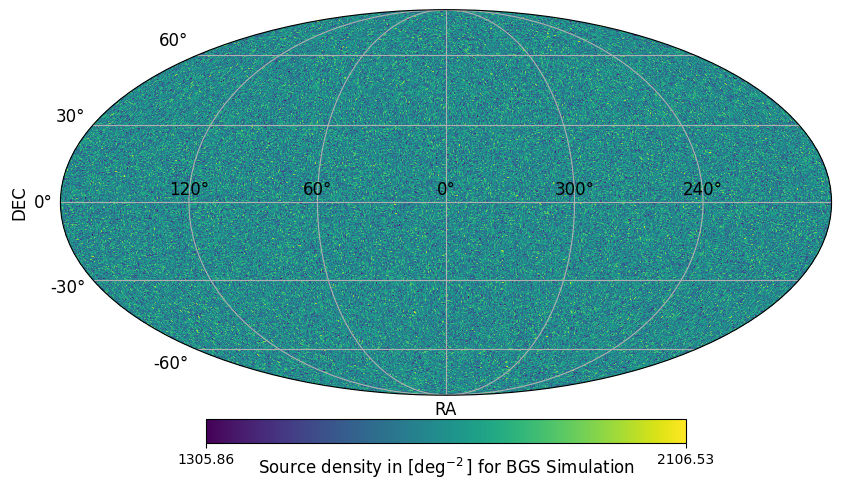

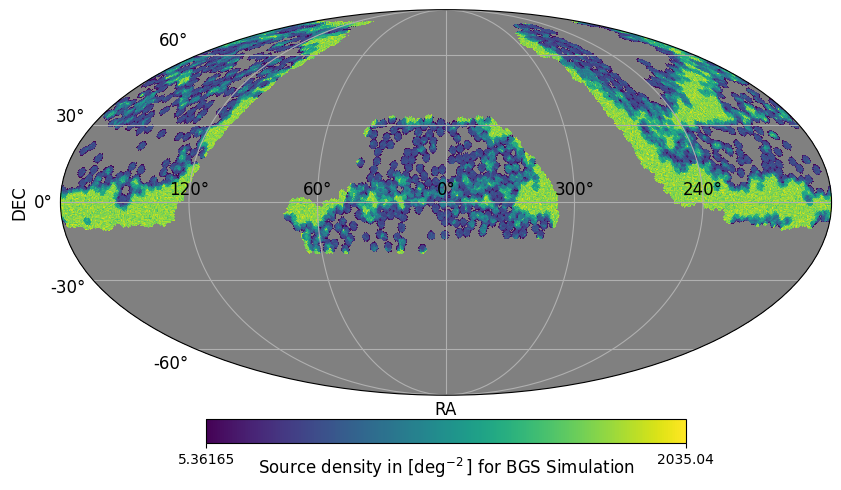

/home/victoria/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


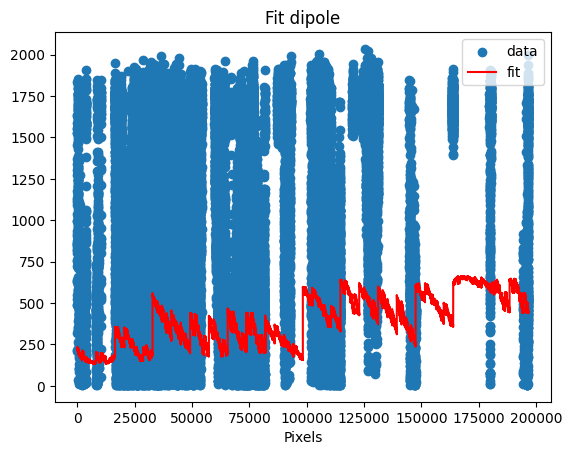

In [10]:
hpmap = np.random.poisson(NSource_px_th, npix)/area_deg2
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.plot('')

hpmap = simu_Mapper_pois.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.set_mask()

init =  (200, 0, 100, 40)
m = simu_Mapper_pois.fit_dipole("Masked", init)
m

## FRACCOV cut

### From QSO

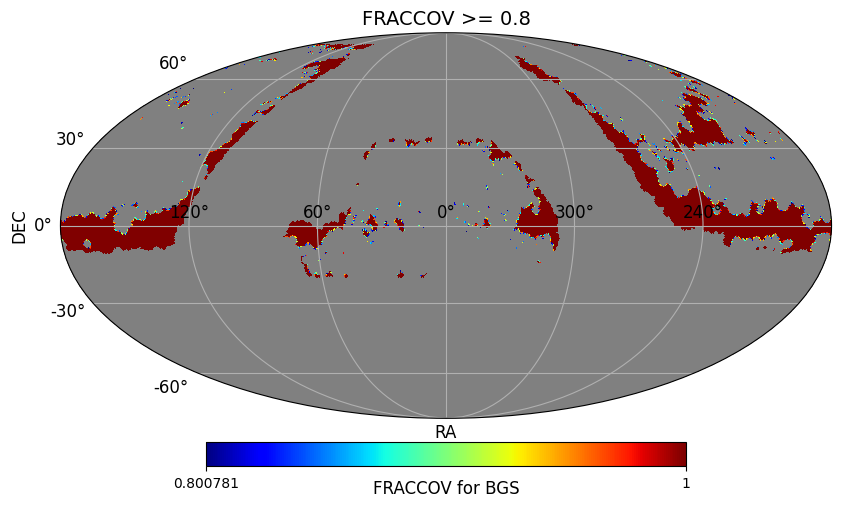

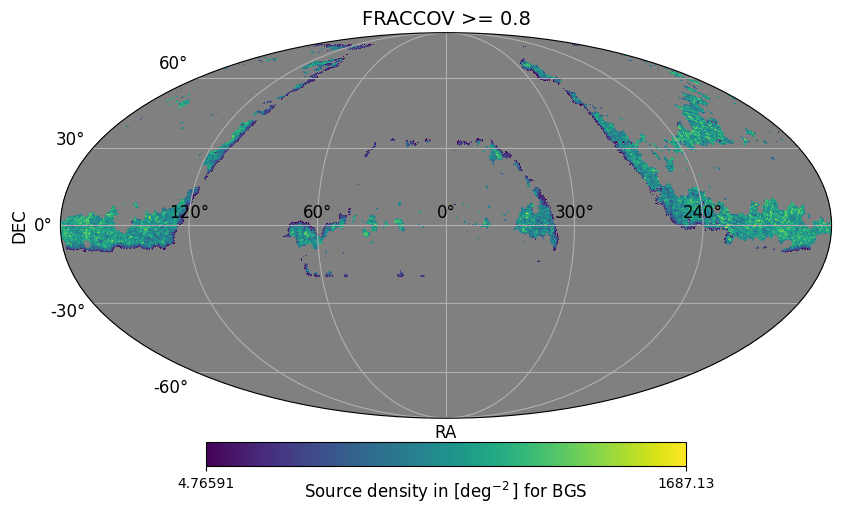

In [11]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'

DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title=title)

ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
ALL_Mapper.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.306e+06 (χ²/ndof = 27.0) │              Nfcn = 325              │
│ EDM = 1.3e-05 (Goal: 0.0002)     │           time = 14.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  366.08   │   0.20    │   -0.20    │    0.20    │    0    │         │       │
│ 1 │ A    │ 771.9e-3  │  0.8e-3   │  -0.8e-3   │   0.8e-3   │    0    │    1    │       │
│ 2 │ ra   │  207.96   │   0.06    │   -0.06    │    0.06    │    0    │   360   │       │
│ 3 │ dec  │  -25.11   │   0.08    │   -0.08    │    0.08    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.2    │    0.2    │  -0.8e-3  │  0.8e-3   │   -0.06   │   0.06    │   -0.08   │   0.08    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0407 -60.6e-6   0.0024   -0.011 │
│   A │ -60.6e-6 7.01e-07  -0.7e-6   3.5e-6 │
│  ra │   0.0024  -0.7e-6  0.00314  -0.0014 │
│ dec │   -0.011   3.5e-6  -0.0014  0.00719 │
└─────┴─────────────────────────────────────┘

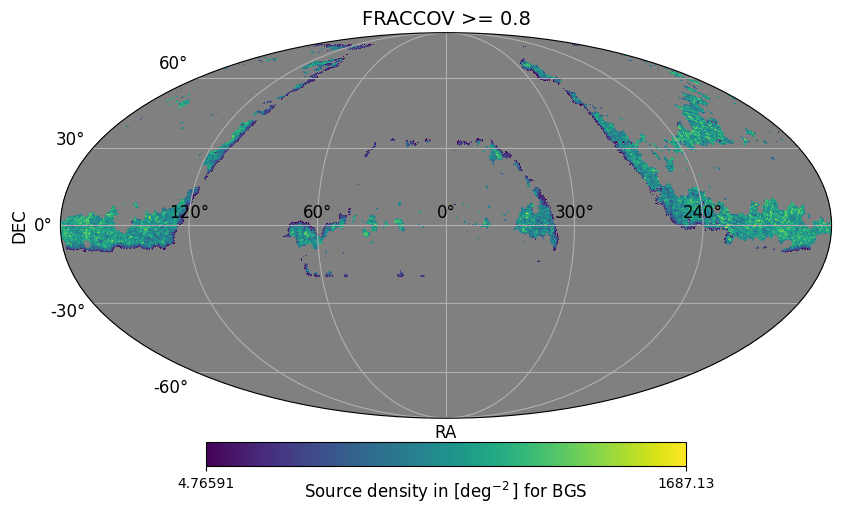

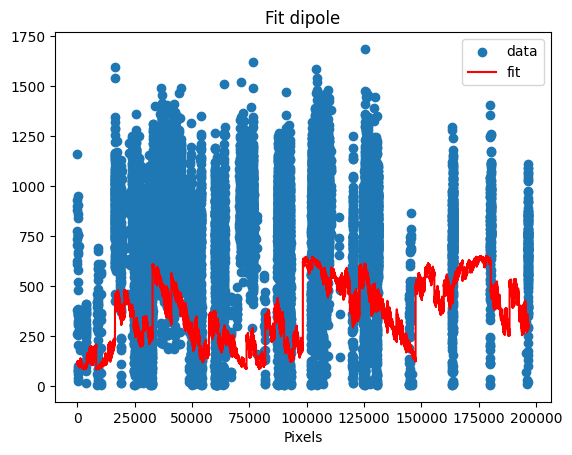

In [12]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.251e+05 (χ²/ndof = 0.6)  │              Nfcn = 928              │
│ EDM = 2.41e-06 (Goal: 0.0002)    │           time = 50.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.65749e3 │ 0.00032e3 │ -0.00032e3 │ 0.00032e3  │    0    │         │       │
│ 1 │ A    │ 0.06e-12  │5282635.94e-12│ -0.06e-12  │5282635.94e-12│    0    │    1    │       │
│ 2 │ ra   │    2.2    │   318.6   │    -2.2    │   318.6    │    0    │   360   │       │
│ 3 │ dec  │    50     │    90     │    -90     │     40     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.32   │   0.32    │ -0.06e-12 │5282635.94e-12│   -2.2    │   318.6   │    -90    │    40     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   False   │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   False   │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   True    │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────────────┐
│     │                N*                 A                ra               dec │
├─────┼─────────────────────────────────────────────────────────────────────────┤
│  N* │               0.1      483.1019e-15              0.00             -0.01 │
│   A │      483.1019e-15          1.31e-18   554.7178988e-12 -38.1166072965e-9 │
│  ra │              0.00   554.7178988e-12          3.12e+03                -0 │
│ dec │             -0.01 -38.1166072965e-9                -0          2.52e+04 │
└─────┴─────────────────────────────────────────────────────────────────────────┘

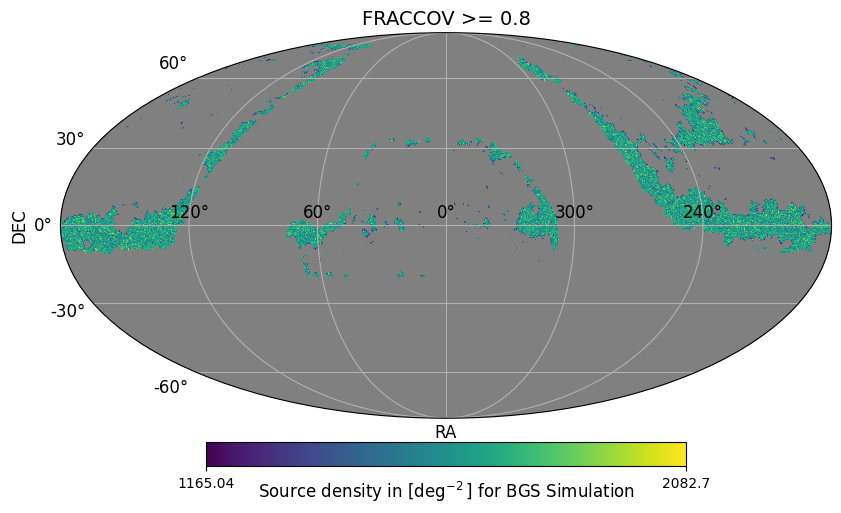

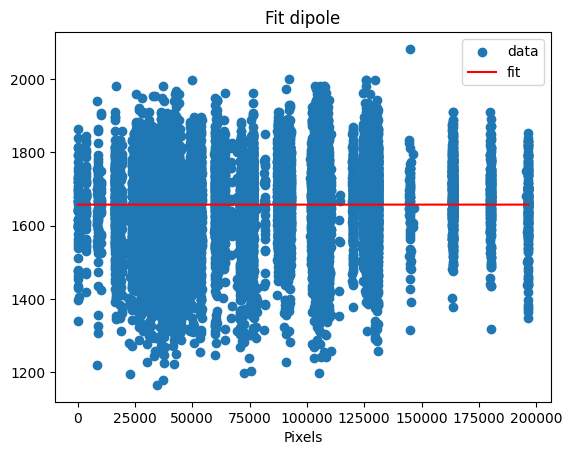

In [13]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'
DR1_Mapper.cut_FracCov(frac_min=frac_min)
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask)

init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Density count > min and FRACCOV > 0.9

### From QSO

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


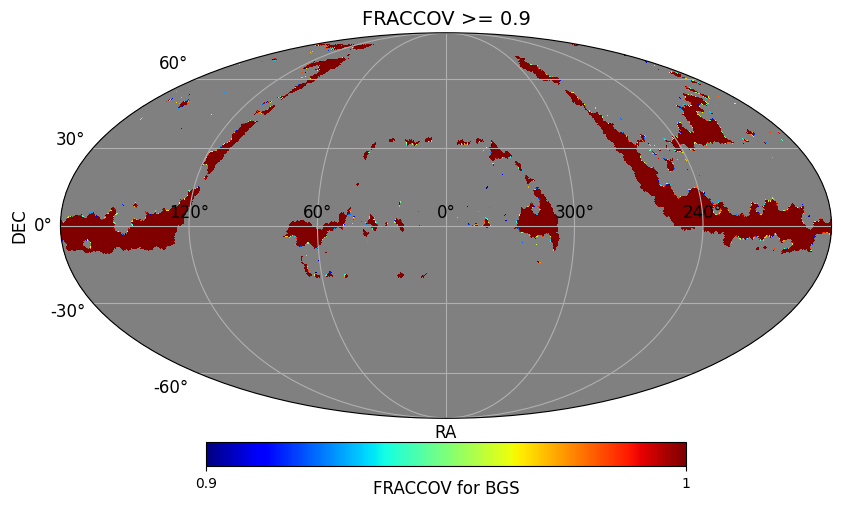

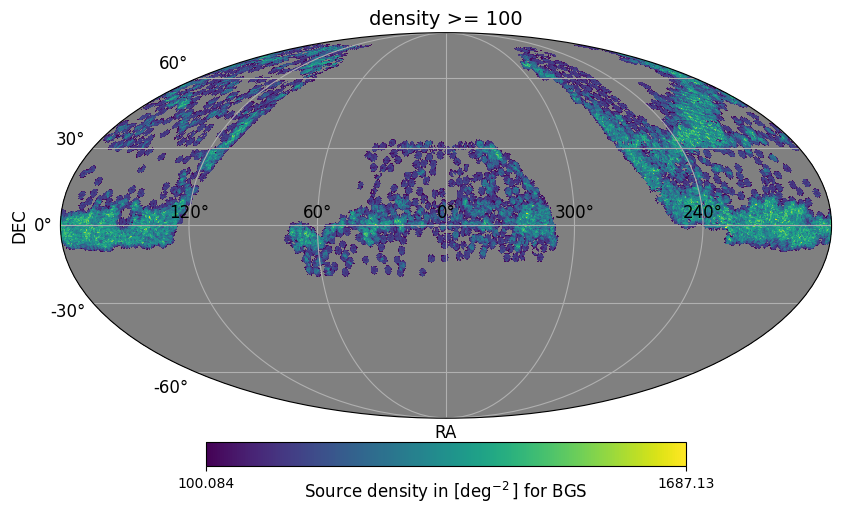

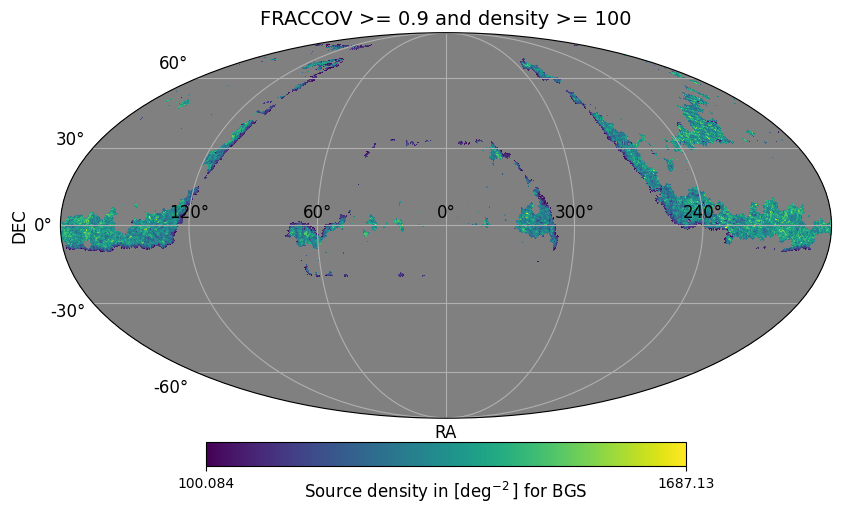

In [14]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
ALL_Mapper.select_bounds(map_min=count_min)
ALL_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
ALL_Mapper.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.687e+06 (χ²/ndof = 8.6)  │              Nfcn = 458              │
│ EDM = 2.34e-05 (Goal: 0.0002)    │           time = 24.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  634.47   │   0.30    │   -0.30    │    0.30    │    0    │         │       │
│ 1 │ A    │ 368.7e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │    0    │    1    │       │
│ 2 │ ra   │  204.06   │   0.10    │   -0.10    │    0.10    │    0    │   360   │       │
│ 3 │ dec  │  -34.15   │   0.15    │   -0.15    │    0.15    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.3    │    0.3    │  -0.7e-3  │  0.7e-3   │   -0.1    │    0.1    │   -0.15   │   0.15    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0908 -24.2e-6    0.004   -0.031 │
│   A │ -24.2e-6 5.24e-07   5.1e-6 -31.4e-6 │
│  ra │    0.004   5.1e-6   0.0105   -0.003 │
│ dec │   -0.031 -31.4e-6   -0.003   0.0237 │
└─────┴─────────────────────────────────────┘

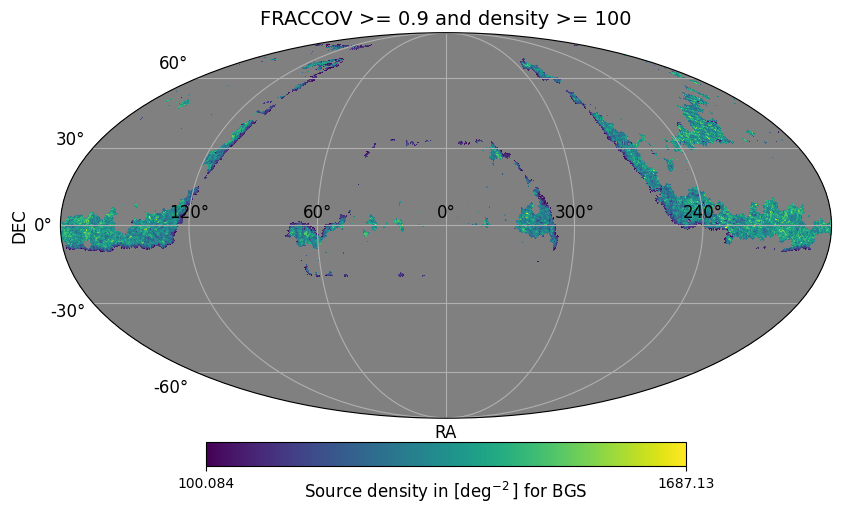

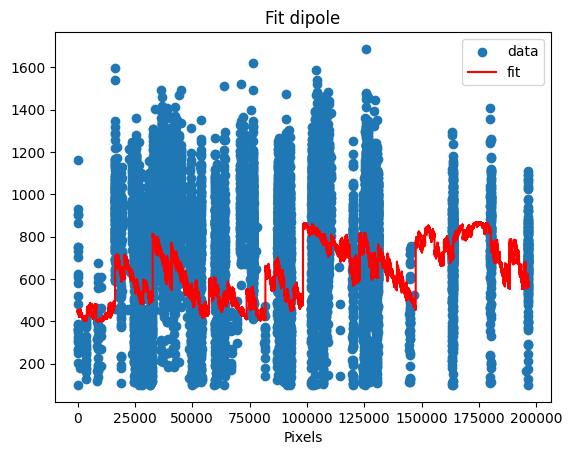

In [15]:
init =  (200, 0, 100, 40)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


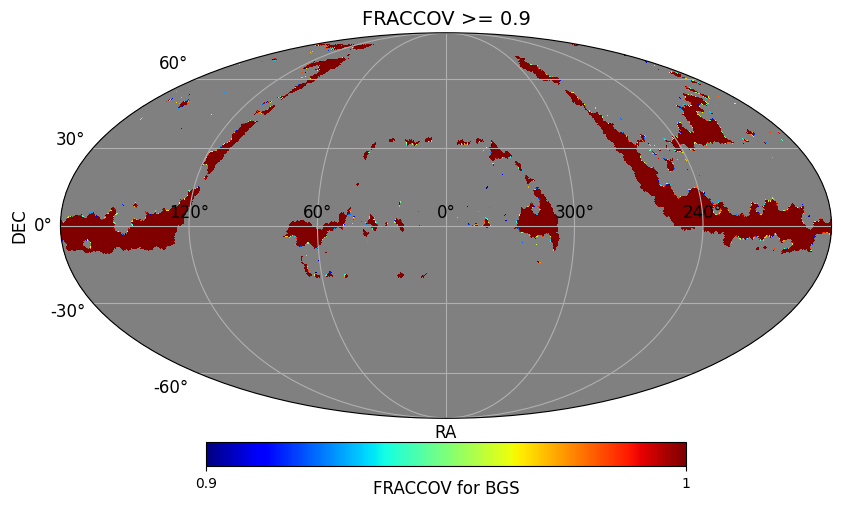

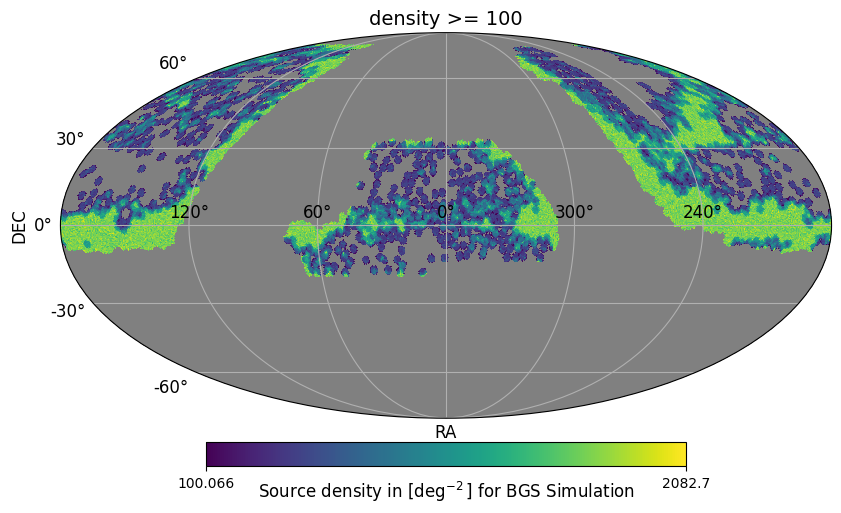

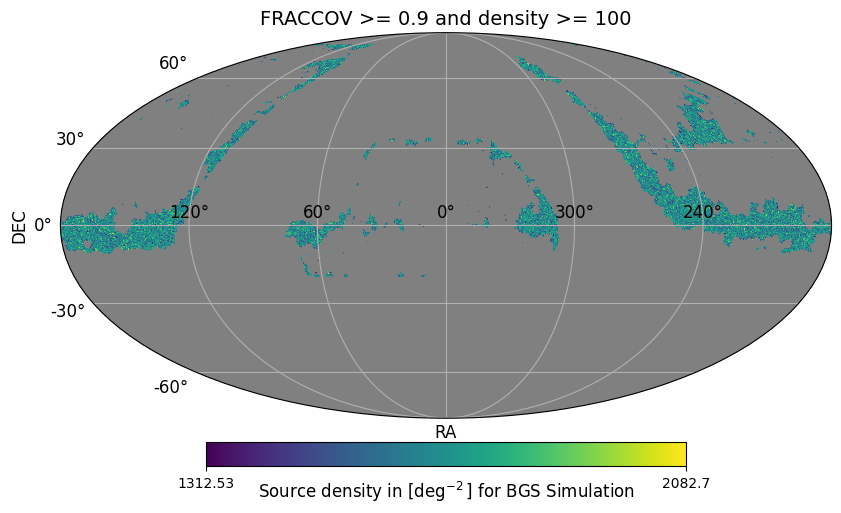

In [16]:
frac_min = 0.9
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
simu_Mapper_scale.select_bounds(map_min=count_min)
simu_Mapper_scale.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
simu_Mapper_scale.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.743e+04 (χ²/ndof = 0.4)  │              Nfcn = 928              │
│ EDM = 9.77e-06 (Goal: 0.0002)    │           time = 53.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.67773e3 │ 0.00011e3 │ -0.00011e3 │ 0.00011e3  │    0    │         │       │
│ 1 │ A    │  4.94e-3  │  0.17e-3  │  -0.17e-3  │  0.17e-3   │    0    │    1    │       │
│ 2 │ ra   │   0.23    │  184.91   │   -0.23    │   184.91   │    0    │   360   │       │
│ 3 │ dec  │-89.99999996│10.54118683│-0.00000004 │10.54118683 │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.11   │   0.11    │ -0.17e-3  │  0.17e-3  │   -0.23   │  184.91   │ -0.04e-6  │10541186.83e-6│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │             N*              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│  N* │         0.0119       1.087e-6         43.018        -0.3e-6 │
│   A │       1.087e-6       3.03e-08 -137.748405e-3       0.001e-6 │
│  ra │         43.018 -137.748405e-3       5.02e+10   -299.0621602 │
│ dec │        -0.3e-6       0.001e-6   -299.0621602       1.78e-06 │
└─────┴─────────────────────────────────────────────────────────────┘

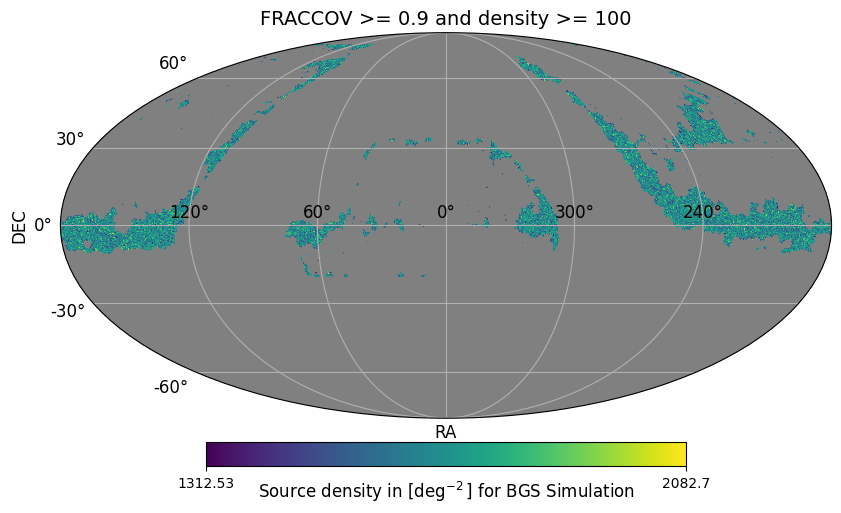

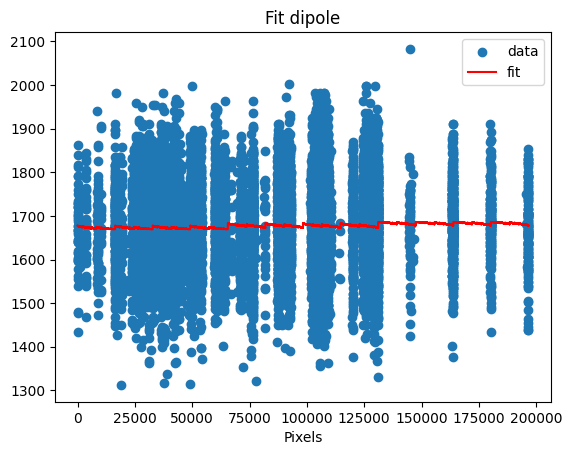

In [17]:
init =  (200, 0, 100, 40)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Correcting data

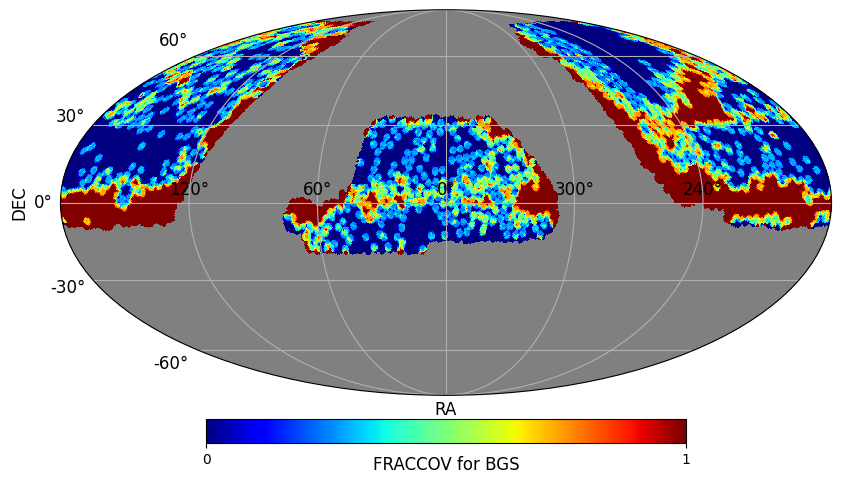

In [18]:
DR1_Mapper.plot("nside")

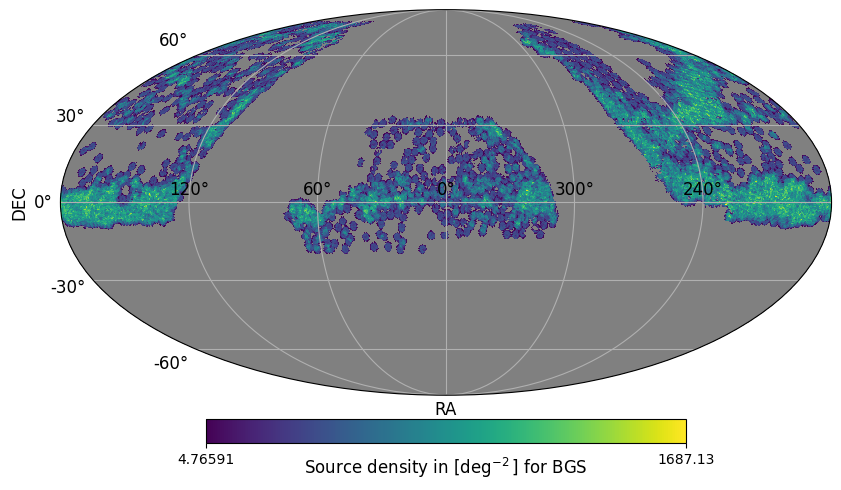

In [19]:
ALL_Mapper.plot("Masked")

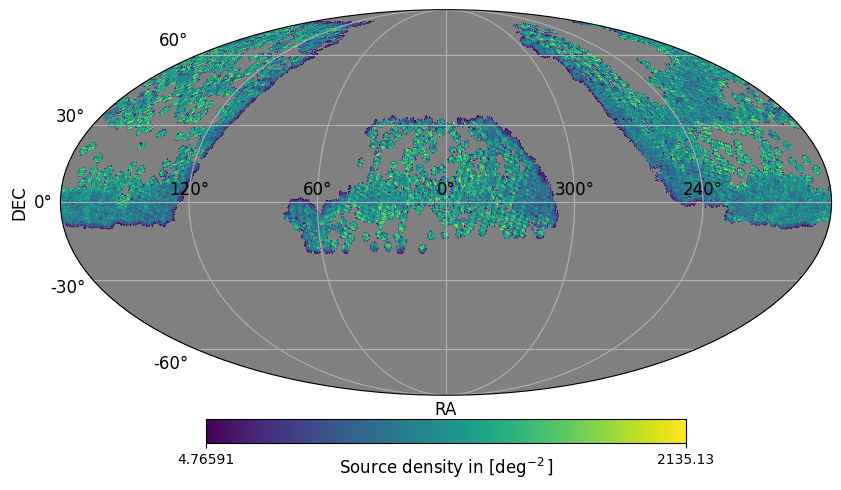

In [20]:
ALLCorrectMapper = DensityMapper.from_map((ALL_Mapper.map / DR1_Mapper.FRACCOVnside).data.data)
ALLCorrectMapper.set_mask()
ALLCorrectMapper.plot("Masked")

In [36]:
mask = DR1_Mapper.FRACCOVnside.data.data == 1
mask2 = ALL_Mapper.map < 4.8
DR1_Mapper.FRACCOVnside.data[mask2 & mask & ~ALL_Mapper.mapMasked.mask]

masked_array(data=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,
                   1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,
                   1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,
                   1.0],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False],
       fill_value=1e+20)

In [37]:
ALL_Mapper.map[mask2 & mask & ~ALL_Mapper.mapMasked.mask]

array([4.76591241, 4.76591241, 4.76591241, 4.76591241, 4.76591241,
       4.76591241, 4.76591241, 4.76591241, 4.76591241, 4.76591241,
       4.76591241, 4.76591241, 4.76591241, 4.76591241, 4.76591241,
       4.76591241, 4.76591241, 4.76591241, 4.76591241, 4.76591241,
       4.76591241, 4.76591241, 4.76591241, 4.76591241, 4.76591241,
       4.76591241, 4.76591241, 4.76591241, 4.76591241, 4.76591241,
       4.76591241, 4.76591241, 4.76591241, 4.76591241])

In [30]:
ALL_Mapper.map[mask2] / DR1_Mapper.FRACCOVnside.data[mask2]

masked_array(data=[0.0, --, 36.22093432192179, ..., 0.0, 0.0, 0.0],
             mask=[False,  True, False, ..., False, False, False],
       fill_value=1e+20)

## Introducing clustering

In [38]:
DIRcl = "Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
FILEcl = DIRcl + sufix + '.fits'

data = fitsio.FITS(FILEcl)
data


  file: Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

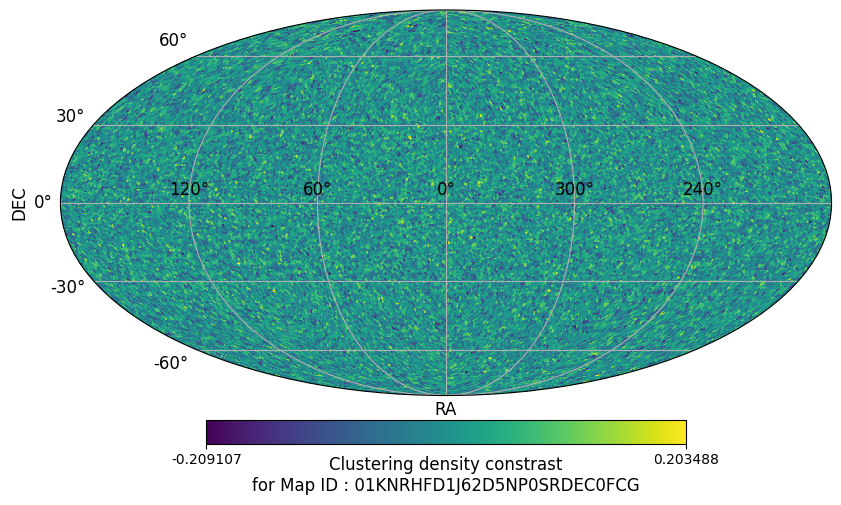

In [39]:
from Simulation.mappers import CountMapper

mapID, hpmap = data['MAPS'][0] #first clustering map
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")
clMapper.plot()

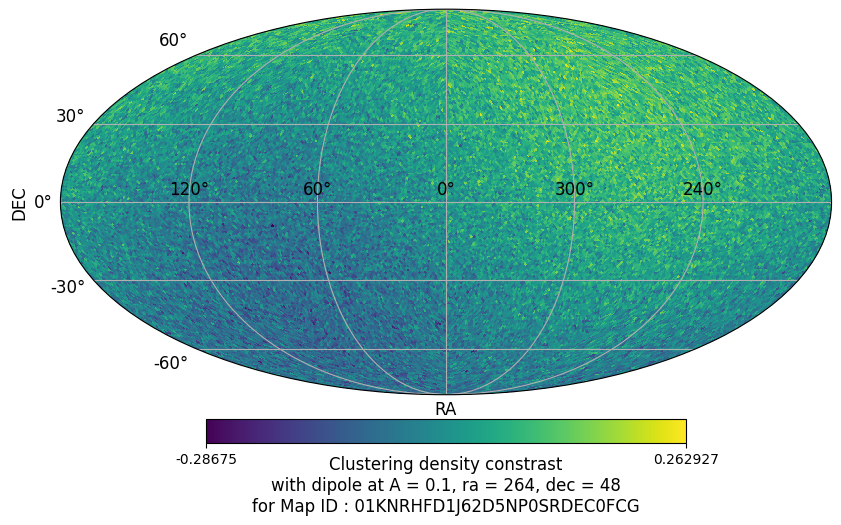

In [40]:
A, ra, dec = 0.1, 264, 48
clDipole = apply_dipole_MD(clMapper.map, clMapper.map, A, ra, dec, nest=True)
clDipoleMapper = CountMapper.from_map(clDipole)
clDipoleMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nwith dipole at A = {A}, ra = {ra}, dec = {dec}\nfor Map ID : {mapID}")
clDipoleMapper.plot()

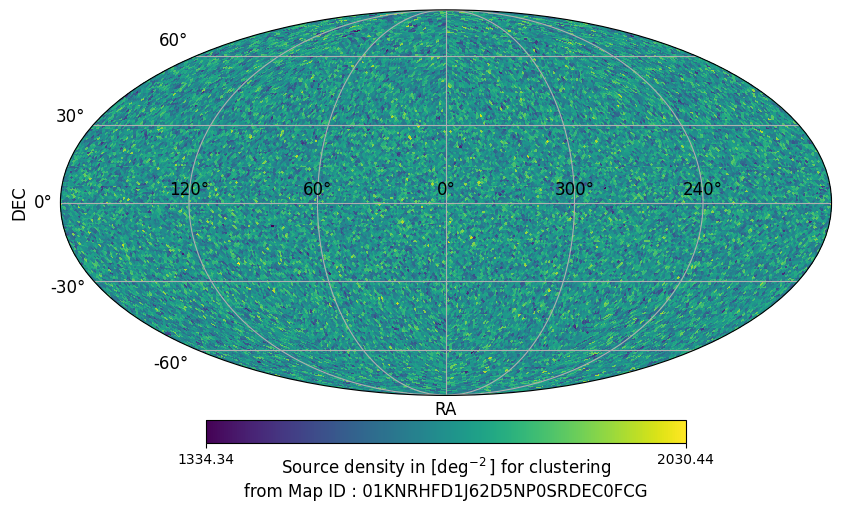

In [41]:
clMonop = apply_monopole_Mcontrast(clMapper.map, NSource_px_th/area_deg2)
clMonopMapper = DensityMapper.from_map(clMonop)
clMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}")
clMonopMapper.plot()

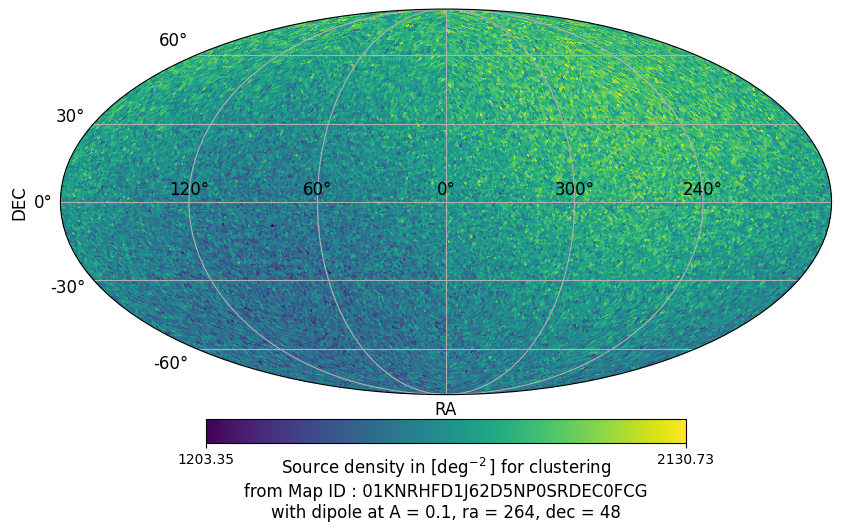

In [42]:
clDipMonop = apply_monopole_Mcontrast(clDipoleMapper.map, NSource_px_th/area_deg2)
clDipMonopMapper = DensityMapper.from_map(clDipMonop)
clDipMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}\nwith dipole at A = {A}, ra = {ra}, dec = {dec}")
clDipMonopMapper.plot()